# Fourieroptik Teil A: Simulationen zur Veranschaulichung des Experiments

### der Slider funktioniert leider nicht auf dem Jupyter Server, nutzen Sie auf dem Server daher bitte die statische Variante
In diesem Jupyter Notebook ist eine numerische Simulation für den Einfachspalt enthalten, die Sie nutzen können, um das Experiment besser zu verstehen. Diese Simulation ist auch für das Verständnis des Gitters nützlich, da über die Breite der Spalte des Gitters wie Einfachspalte wirken und die Einhüllende des Beugungsbilds definieren.

Für das Protokoll zu Versuchsteil A können Sie Abbildungen aus diesem Jupyter Notebook zur Gegenüberstellung von Experiment und Theorie nutzen. Alternativ können Sie zur Veranschaulichung eigene Simulationen oder Tools aus dem Internet (z.B. falstad) nutzen. Geben Sie in diesem Fall bitte die Quelle an.


In [1]:
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider  # import the Slider widget

## Simulation zum Experiment: Berechnung des Objektbilds als Fourierrücktransformierte des Beugungsbildes am Beispiel des Einzelspalts

Hier wird anhand der in der Versuchsanleitung angegebenen Formel $f_{modifiziert}(y)$ die Fourierrücktransformierte des Beugungsbildes des Einzelspalts bei begrenzter Anzahl von Beugungsordnungen numerisch berechnet. Nutzen Sie diese Simulation, um sich zu veranschaulichen, was im Experiment passiert und stellen Sie im Protokoll Experiment und Simulation gegenüber.

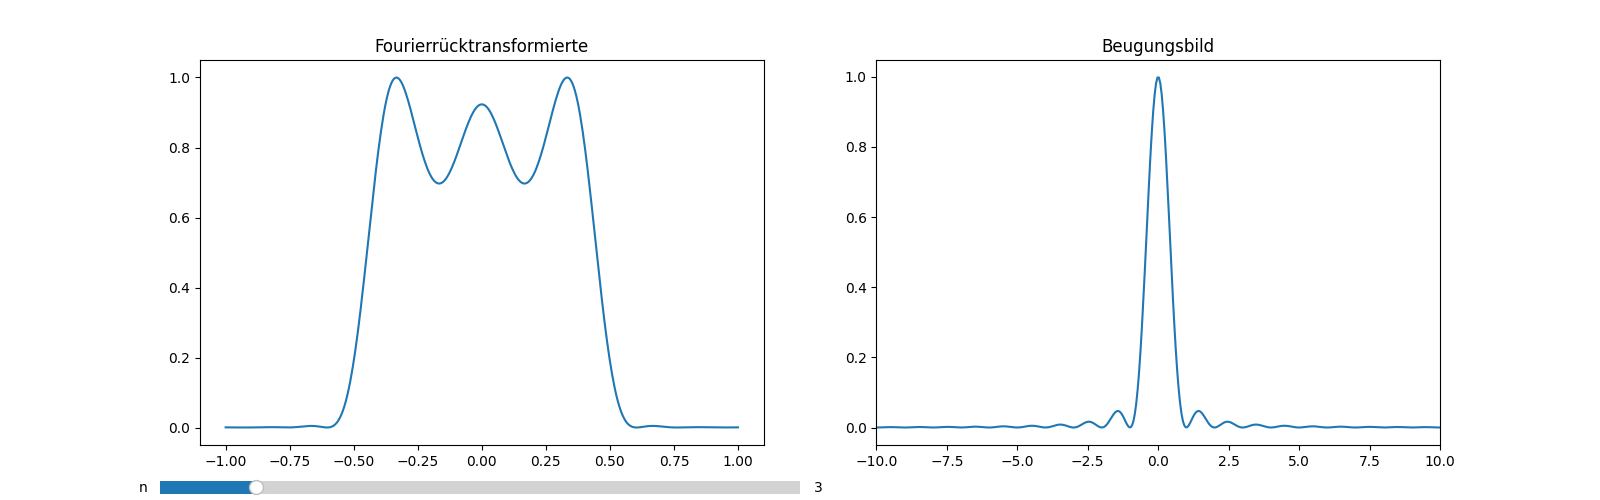

In [2]:
from scipy.integrate import quad

d=1 #Spaltbreite auf 1 setzen
n=3 #Integrationsbereich
Y=np.linspace(-1,1,400)*d

# Fourierrücktransformierte des Beugungsbildes des Einzelspalts
def spalt(k,y):
   return d/np.pi*np.sin(k*d/2)/(k*d/2)*np.cos(y*k)

# Fourierrücktransformierte bei Integration bis zur n-ten Beugungsordnung
def spalt_mod(n):
    f_modifiziert=[]
    for i in range(len(Y)):
        y=Y[i]
        result, error = quad(spalt, 0, 2*np.pi*n/d , args=(y,))
        f_modifiziert.append(result**2)
    #Kurve auf 1 normieren:
    f_modifiziert=f_modifiziert/np.max(f_modifiziert)
    return f_modifiziert

# Beugungsbild des Einzelspalts
def spalt_beugung(k):
    return (d/np.pi*np.sin(np.pi*k*d)/(k*d))**2

def beugung_x(n):
    f_modifiziert=[]
    f_modifiziert=np.linspace(-n,n,400)
    return f_modifiziert

def beugung_mod(n):
    f_modifiziert=[]
    x_mod=np.linspace(-n,n,400)
    f_modifiziert=spalt_beugung(x_mod)
    return f_modifiziert

fig, axs = plt.subplots(1,2, figsize=(16,5))

n_min = 0    # Minimum n der Fouriersumme
n_max = 20   # Maximum n der Fouriersumme
n_init = 3   # Startwert n der Fouriersumme

fourier_ax = axs[0]
beugung_ax=axs[1]
slider_ax = plt.axes([0.1, 0.00, 0.4, 0.05])
axs[1].set_title("Beugungsbild")
axs[0].set_title("Fourierrücktransformierte")

x_0=np.linspace(-10,10,400)
y=spalt_beugung(x_0)

plt.axes(beugung_ax)
beugung_plot, = plt.plot(x_0, y)
plt.xlim(-10,10)

plt.axes(fourier_ax)
fourier_plot, = plt.plot(Y,spalt_mod(3))


n_slider = Slider(slider_ax,         # Ein Schiebegler der die Anzahl n der Summanden n
                  # der Fourierreihe einstellt
                  'n',               # Name n des Index der Fouriersumme
                  n_min,             # Minimum n der Fouriersumme
                  n_max,             # Maximum n der Fouriersumme
                  valinit = n_init,  # Startwert n der Fouriersumme
                  valstep = 1        # Schrittweite des Reglers, nur ganzzahlige Werte
                  )

# Definieren wir eine Funktion (update), die jedes Mal ausgeführt wird, wenn sich der Wert
# des Schiebereglers ändert. Der Variablen dieser Funktion wird
# der Wert des Schiebereglers zugewiesen.

def update(val):
    n = int(n_slider.val)
    fourier_plot.set_ydata(spalt_mod(n))
    beugung_plot.set_xdata(beugung_x(n))
    beugung_plot.set_ydata(beugung_mod(n))
    fig.canvas.draw_idle()          # Funktion neu zeichnen

# obige Funktion (update) wird ausgeführt, wenn sich der Wert des Schiebereglers ändert
n_slider.on_changed(update)

plt.show()